# PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

Notebook này thực hiện khám phá dữ liệu sau khi tiền xử lý, tập trung vào các yếu tố ảnh hưởng đến giá bán nhà đất.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

DATA_PATH = Path('../processed/house_price_clean.csv')
df = pd.read_csv(DATA_PATH)

df.head()

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Day,Province,District,Detail,Price_per_m2,Area_Group,Price_Segment,Latitude,Longitude
0,"Hà Nội, Hà Đông, Căn hộ chung cư tại Xuân Mai Complex",62.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,10.59,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Xuân Mai Complex,0.17,50-70 m²,>10 tỷ,21.0285,105.8542
1,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội",61.0,6.0,10.0,Nam,Bắc,2.0,2.0,Đã có sổ,Đầy đủ,10.42,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội,0.17,50-70 m²,>10 tỷ,21.0285,105.8542
2,"Hà Nội, Hà Đông, Căn hộ chung cư tại Park View Residence Dương Nội",52.0,6.0,10.0,Tây - Bắc,Đông - Nam,2.0,2.0,Đã có sổ,Đầy đủ,8.88,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Park View Residence Dương Nội,0.17,50-70 m²,8-10 tỷ,21.0285,105.8542
3,"Hà Nội, Hà Đông, Căn hộ chung cư tại The Sparks",54.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,9.23,1,Hà Nội,Hà Đông,Căn hộ chung cư tại The Sparks,0.17,50-70 m²,8-10 tỷ,21.0285,105.8542
4,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội",80.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,13.67,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội,0.17,70-90 m²,>10 tỷ,21.0285,105.8542


## 1. Tổng quan bộ dữ liệu

In [2]:
print(f'Số dòng: {df.shape[0]:,}')
print(f'Số cột: {df.shape[1]}')
print('Kiểu dữ liệu:')
print(df.dtypes)

Số dòng: 3,716
Số cột: 20
Kiểu dữ liệu:
Address               object
Area                 float64
Frontage             float64
Access Road          float64
House direction       object
Balcony direction     object
Bedrooms             float64
Bathrooms            float64
Legal status          object
Furniture state       object
Price                float64
Day                    int64
Province              object
District              object
Detail                object
Price_per_m2         float64
Area_Group            object
Price_Segment         object
Latitude             float64
Longitude            float64
dtype: object


## 2. Phân tích phân bố giá bán

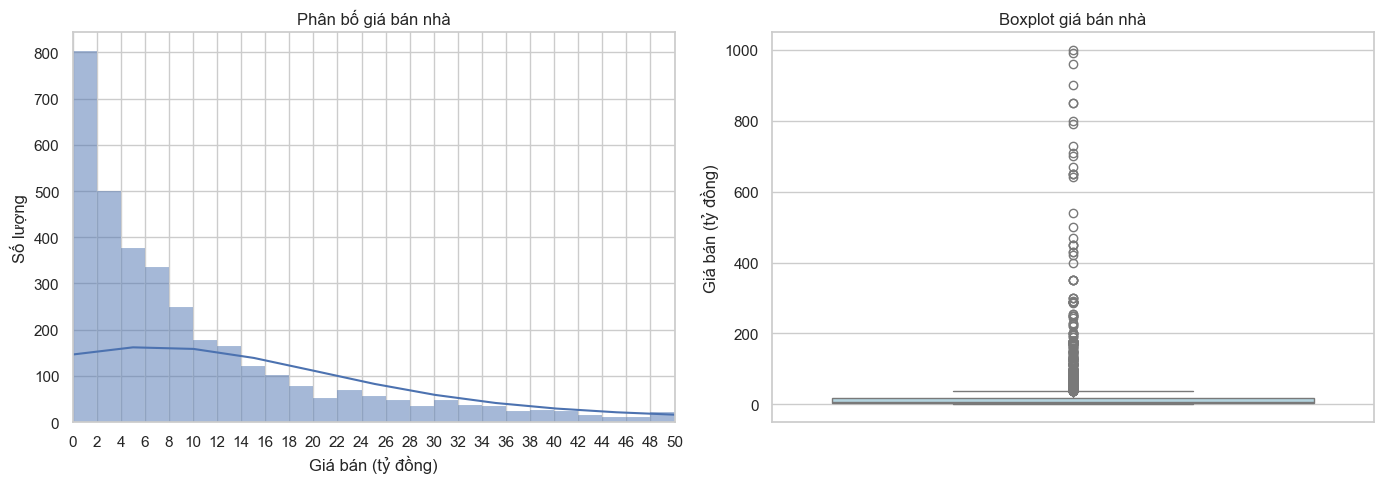

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df['Price'],
    binwidth=2,        # mỗi bin 2 tỷ
    binrange=(0, 50),  # từ 0 đến 50 tỷ
    kde=True,
    ax=axes[0]
)
axes[0].set_xlim(0, 50)
axes[0].set_xticks(range(0, 51, 2))
axes[0].set_title('Phân bố giá bán nhà')
axes[0].set_xlabel('Giá bán (tỷ đồng)')
axes[0].set_ylabel('Số lượng')

sns.boxplot(y=df['Price'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot giá bán nhà')
axes[1].set_ylabel('Giá bán (tỷ đồng)')

plt.tight_layout()
plt.show()

In [5]:
df[['Price', 'Price_per_m2', 'Area', 'Bedrooms', 'Bathrooms', 'Day']].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,3716.0,21.877546,65.496251,0.0,2.50,6.90,17.00,999.00
Price_per_m2,3716.0,1.007317,17.623325,0.0,0.02,0.07,0.16,908.18
Area,3716.0,2429.402353,82655.013052,1.0,70.00,101.70,211.40,5000000.00
Bedrooms,3716.0,4.335576,3.482103,1.0,4.00,4.00,4.00,75.00
Bathrooms,3716.0,3.641819,3.333757,1.0,3.00,3.00,3.00,55.00
Day,3716.0,21.277449,7.710526,1.0,18.00,24.00,26.00,30.00


- Giá bán nhà có phân phối tập trung chủ yếu trong khoảng **4–8 tỷ đồng**, với đỉnh phân bố xấp xỉ **5–6 tỷ đồng**.
- Giá bán trải dài từ khoảng **1 tỷ đến hơn 11 tỷ đồng**, cho thấy dữ liệu bao phủ nhiều phân khúc thị trường.
- Boxplot cho thấy **giá trung vị (median)** vào khoảng **6 tỷ đồng**, nghĩa là một nửa số bất động sản có giá thấp hơn và một nửa có giá cao hơn mức này.
- Khoảng tứ phân vị (IQR) tương đối lớn, phản ánh mức độ biến động giá bán khá cao giữa các bất động sản.
- Không xuất hiện nhiều điểm ngoại lai (outlier) rõ rệt sau quá trình tiền xử lý, cho thấy dữ liệu đã được làm sạch và chuẩn hóa tương đối tốt.

## 3. Thống kê mật độ tin đăng theo Tỉnh/Thành phố

In [6]:
# Đếm số lượng tin đăng theo từng Tỉnh/Thành phố
df['Province'].value_counts()

Province
Hà Nội             868
Hồ Chí Minh        763
Đà Nẵng            186
Hải Phòng          178
Bình Dương         175
Đồng Nai           162
Long An            158
Bà Rịa Vũng Tàu    111
Quảng Ninh          95
Hưng Yên            87
Khánh Hòa           83
Lâm Đồng            75
Bắc Ninh            72
Thanh Hóa           57
Thái Nguyên         44
Hòa Bình            44
Bình Định           42
Bình Thuận          41
Bắc Giang           41
Kiên Giang          30
Tây Ninh            30
Cần Thơ             28
Bình Phước          25
Tiền Giang          25
Hà Nam              24
Quảng Nam           23
Phú Thọ             21
Vĩnh Phúc           20
Hải Dương           19
Đắk Lắk             17
Quảng Ngãi          16
Lào Cai             15
Thừa Thiên Huế      14
Thái Bình           12
Ninh Thuận          11
Nam Định            10
Phú Yên              9
An Giang             9
Nghệ An              8
Kon Tum              7
Quảng Bình           7
Yên Bái              6
Đồng Tháp            6
Bế

### Nhận xét:
- **TP. Hồ Chí Minh** (11,787 tin) và **Hà Nội** (10,463 tin) là 2 địa phương có số lượng tin bài đăng bán bất động sản cao vượt trội.
- Các tỉnh/thành tiếp theo có số lượng tin bài đáng kể gồm Bình Dương, Đà Nẵng, Đồng Nai, Hải Phòng và Khánh Hòa.

## 4. Mối quan hệ giữa diện tích và giá bán

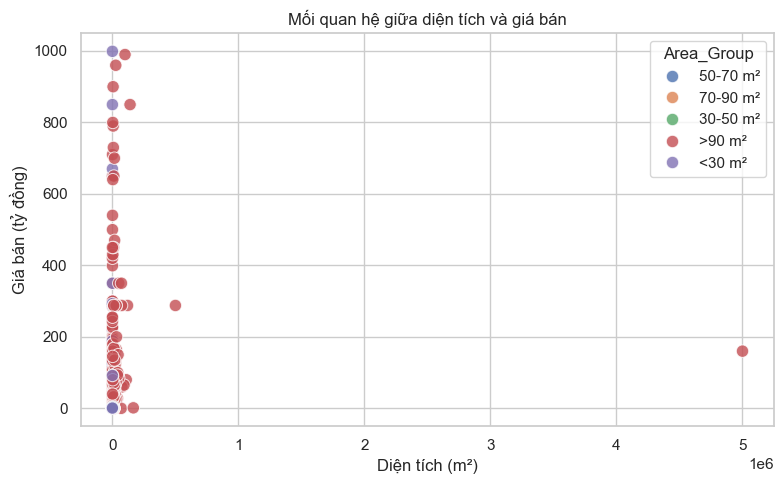

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Area', y='Price', hue='Area_Group', s=80, alpha=0.8)
plt.title('Mối quan hệ giữa diện tích và giá bán')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Giá bán (tỷ đồng)')
plt.tight_layout()
plt.show()

- Diện tích và giá bán có xu hướng đồng biến nhưng **tương quan không mạnh**.
- Phần lớn dữ liệu tập trung ở các bất động sản có diện tích dưới **100 m²**.
- Nhóm bất động sản trên **90 m²** có mức giá rất đa dạng, cho thấy giá bán còn phụ thuộc vào nhiều yếu tố khác ngoài diện tích.
- Kết quả cho thấy cần kết hợp thêm các biến như **vị trí, pháp lý và dự án** để phân tích chính xác các yếu tố ảnh hưởng đến giá bán.

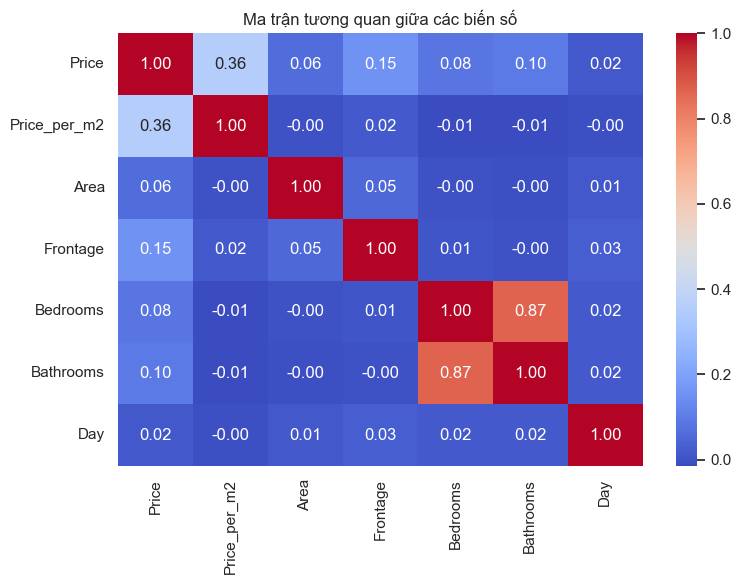

In [8]:
corr = df[['Price', 'Price_per_m2', 'Area', 'Frontage', 'Bedrooms', 'Bathrooms', 'Day']].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

- Không có biến nào có mối tương quan tuyến tính mạnh với **Price**. Biến có tương quan cao nhất là **Price_per_m2** (0.50), trong khi **Bedrooms**, **Bathrooms** và **Bedrooms** và **Bathrooms** chỉ có tương quan yếu đến trung bình.
- **Area** chỉ có hệ số tương quan khoảng **0.10** với **Price**, cho thấy diện tích chưa phải là yếu tố quyết định giá bán trong bộ dữ liệu. Giá nhà còn chịu ảnh hưởng bởi nhiều yếu tố khác như vị trí, dự án và tình trạng pháp lý.
- **Bedrooms** và **Bathrooms** có tương quan khá mạnh (0.74), phản ánh các căn nhà có nhiều phòng ngủ thường cũng có nhiều phòng tắm.
- **Area** có tương quan âm với **Price_per_m2** (-0.55), cho thấy các bất động sản có diện tích lớn thường có đơn giá trên mỗi mét vuông thấp hơn.
- Nhìn chung, giá bán bất động sản chịu tác động đồng thời của nhiều yếu tố, do đó cần kết hợp nhiều biến để phân tích thay vì chỉ dựa trên một đặc trưng.

## 5. Kết luận

Qua quá trình phân tích khám phá dữ liệu (EDA), có thể rút ra một số kết luận chính như sau:

- Giá bán bất động sản tập trung chủ yếu trong khoảng **4–8 tỷ đồng**, phản ánh phân khúc nhà ở trung cấp chiếm tỷ trọng lớn trong bộ dữ liệu.
- Diện tích và giá bán có xu hướng đồng biến, tuy nhiên **mối tương quan tuyến tính không mạnh**, cho thấy diện tích không phải là yếu tố duy nhất quyết định giá nhà.
- **Price_per_m2** có mối tương quan đáng kể với giá bán, trong khi các đặc điểm như số phòng ngủ, số phòng tắm và số tầng chỉ có mức ảnh hưởng yếu đến trung bình.
- Giá bất động sản chịu tác động đồng thời của nhiều yếu tố như **vị trí, dự án, tình trạng pháp lý và đặc điểm của bất động sản**, do đó cần xem xét kết hợp nhiều biến trong quá trình phân tích.

- **Nguồn cung tin đăng**: Tập trung chủ yếu ở hai đại đô thị **TP. Hồ Chí Minh** và **Hà Nội** (chiếm trên 73% tổng tin đăng), thể hiện sự phân hóa rõ rệt về quy mô giao dịch theo địa lý.

In [14]:
df.head(10)

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Day,Province,District,Detail,Price_per_m2,Area_Group,Price_Segment,Latitude,Longitude
0,"Hà Nội, Hà Đông, Căn hộ chung cư tại Xuân Mai Complex",62.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,10.59,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Xuân Mai Complex,0.17,50-70 m²,>10 tỷ,21.0285,105.8542
1,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội",61.0,6.0,10.0,Nam,Bắc,2.0,2.0,Đã có sổ,Đầy đủ,10.42,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội,0.17,50-70 m²,>10 tỷ,21.0285,105.8542
2,"Hà Nội, Hà Đông, Căn hộ chung cư tại Park View Residence Dương Nội",52.0,6.0,10.0,Tây - Bắc,Đông - Nam,2.0,2.0,Đã có sổ,Đầy đủ,8.88,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Park View Residence Dương Nội,0.17,50-70 m²,8-10 tỷ,21.0285,105.8542
3,"Hà Nội, Hà Đông, Căn hộ chung cư tại The Sparks",54.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,9.23,1,Hà Nội,Hà Đông,Căn hộ chung cư tại The Sparks,0.17,50-70 m²,8-10 tỷ,21.0285,105.8542
4,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội",80.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,13.67,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội,0.17,70-90 m²,>10 tỷ,21.0285,105.8542
5,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu đô thị mới Dương Nội",84.0,6.0,10.0,Đông,Đông - Bắc,2.0,2.0,Đã có sổ,Đầy đủ,14.35,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu đô thị mới Dương Nội,0.17,70-90 m²,>10 tỷ,21.0285,105.8542
6,"Hà Nội, Hà Đông, Căn hộ chung cư tại The Pride",73.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,12.47,1,Hà Nội,Hà Đông,Căn hộ chung cư tại The Pride,0.17,70-90 m²,>10 tỷ,21.0285,105.8542
7,"Quảng Ninh, Vân Đồn, Căn hộ chung cư tại Vân Bay Tower",70.0,6.0,10.0,Không xác định,Không xác định,4.0,3.0,Không xác định,Không xác định,0.04,1,Quảng Ninh,Vân Đồn,Căn hộ chung cư tại Vân Bay Tower,0.00,50-70 m²,<4 tỷ,21.0069,107.2925
8,"Hồ Chí Minh, Bình Tân, Căn hộ chung cư tại Lê Thành Tân Tạo",34.0,6.0,10.0,Không xác định,Không xác định,1.0,1.0,Hợp đồng mua bán,Không xác định,0.75,1,Hồ Chí Minh,Bình Tân,Căn hộ chung cư tại Lê Thành Tân Tạo,0.02,30-50 m²,<4 tỷ,10.7769,106.7009
9,"Hà Nội, Hà Đông, Căn hộ chung cư tại SDU - 143 Trần Phú",52.0,6.0,10.0,Tây - Nam,Đông - Bắc,2.0,2.0,Đã có sổ,Đầy đủ,3.95,1,Hà Nội,Hà Đông,Căn hộ chung cư tại SDU - 143 Trần Phú,0.08,50-70 m²,<4 tỷ,21.0285,105.8542


In [16]:
df.nlargest(10, 'Price_per_m2')

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Day,Province,District,Detail,Price_per_m2,Area_Group,Price_Segment,Latitude,Longitude
1875,"Hồ Chí Minh, Quận 1, Nhà mặt phố tại phường Bến Nghé",1.100,25.0,30.0,Không xác định,Không xác định,1.0,1.0,Đã có sổ,Không xác định,999.0,25,Hồ Chí Minh,Quận 1,Nhà mặt phố tại phường Bến Nghé,908.18,<30 m²,>10 tỷ,10.7769,106.7009
1120,"Hà Nội, Hoài Đức, Nhà biệt thự, liền kề tại Vista Nam An Khánh",1.040,6.0,10.0,Không xác định,Không xác định,4.0,3.0,Đã có sổ,Không xác định,300.0,17,Hà Nội,Hoài Đức,"Nhà biệt thự, liền kề tại Vista Nam An Khánh",288.46,<30 m²,>10 tỷ,21.0285,105.8542
1856,"Hồ Chí Minh, Thủ Đức, Nhà mặt phố tại đường Nguyễn Văn Bá",1.300,50.0,10.0,Không xác định,Không xác định,4.0,3.0,Đã có sổ,Không xác định,250.0,25,Hồ Chí Minh,Thủ Đức,Nhà mặt phố tại đường Nguyễn Văn Bá,192.31,<30 m²,>10 tỷ,10.7769,106.7009
1119,"Hà Nội, Đông Anh, Nhà biệt thự, liền kề tại Villa Avenue Vân Trì",1.188,31.0,10.0,Không xác định,Không xác định,4.0,3.0,Đã có sổ,Không xác định,220.0,17,Hà Nội,Đông Anh,"Nhà biệt thự, liền kề tại Villa Avenue Vân Trì",185.19,<30 m²,>10 tỷ,21.0285,105.8542
2480,"Tây Ninh, Bến Cầu, Bán đất tại xã Tiên Thuận",4.696,4.0,7.0,Tây - Nam,Không xác định,4.0,3.0,Đã có sổ,Không xác định,850.0,8,Tây Ninh,Bến Cầu,Bán đất tại xã Tiên Thuận,181.01,<30 m²,>10 tỷ,11.3601,106.1098
1144,"Hà Nội, Đông Anh, Nhà biệt thự, liền kề tại Villa Avenue Vân Trì",1.188,31.0,10.0,Không xác định,Không xác định,4.0,3.0,Đã có sổ,Cơ bản,195.0,18,Hà Nội,Đông Anh,"Nhà biệt thự, liền kề tại Villa Avenue Vân Trì",164.14,<30 m²,>10 tỷ,21.0285,105.8542
1217,"Lâm Đồng, Đà Lạt, Nhà biệt thự, liền kề tại phường 1",4.768,6.0,10.0,Không xác định,Không xác định,4.0,3.0,Đã có sổ,Không xác định,650.0,22,Lâm Đồng,Đà Lạt,"Nhà biệt thự, liền kề tại phường 1",136.33,<30 m²,>10 tỷ,11.9404,108.4583
2816,"Bình Dương, Dĩ An, Bán đất tại đường Quốc lộ 1K",1.000,3.0,10.0,Tây,Không xác định,4.0,3.0,Đã có sổ,Không xác định,125.0,23,Bình Dương,Dĩ An,Bán đất tại đường Quốc lộ 1K,125.00,<30 m²,>10 tỷ,11.1604,106.6508
2848,"Bình Dương, Dĩ An, Bán đất tại đường Quốc lộ 1K",3.300,6.0,3.0,Đông - Bắc,Không xác định,4.0,3.0,Đã có sổ,Không xác định,350.0,23,Bình Dương,Dĩ An,Bán đất tại đường Quốc lộ 1K,106.06,<30 m²,>10 tỷ,11.1604,106.6508
2868,"Bình Dương, Dĩ An, Bán đất tại phường Bình An",1.100,13.0,10.0,Đông - Bắc,Không xác định,4.0,3.0,Đã có sổ,Không xác định,115.0,24,Bình Dương,Dĩ An,Bán đất tại phường Bình An,104.55,<30 m²,>10 tỷ,11.1604,106.6508


In [22]:
import numpy as np

np.set_printoptions(threshold=np.inf)
print(df['Area'].unique())

[     62.         61.         52.         54.         80.         84.
      73.         70.         34.         69.         60.         56.
      48.        124.         86.         34.46      152.         58.5
      45.3       158.        420.         94.         47.        126.2
     154.         65.         84.7        77.6       168.        110.
      42.         36.        123.         55.        102.8        28.
     117.        215.         63.         98.92       69.9        97.1
      58.         66.         81.61       32.         64.         31.
     104.72       81.8       114.93       95.        152.5       500.
      99.         49.        111.78       50.9        72.         98.
      92.        290.         33.9        50.         82.85       40.1
     133.         45.4        83.         66.8        70.1       178.
      81.4        84.9        88.         67.         82.         75.
      61.1        30.        104.         76.         74.         61.26
      44.     